Ноутбук с обучением модели детекции LLM сгенерированных новостей. Обучение происходит при помощи GAN подхода

* 1. Инициализация

* 2. Подготовка датасета для генератора

* 3. Моделирование

* 4. PCA разложение

In [3]:
from transformers import DebertaModel, DebertaForSequenceClassification, DebertaTokenizerFast
from sklearn.linear_model import LogisticRegression
from utils_for_colab import try_load, save_s3
from dotenv import load_dotenv
from minio import Minio

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

# 1. Инициализация

In [7]:
load_dotenv()

YANDEX_CLOUD_ACCESS_KEY = os.getenv("AWS_ACCESS_KEY_ID")
YANDEX_CLOUD_SECRET_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")

BUCKET_NAME = 'graduate' # s3

PATH = '/Users/dan/git_repo/graduate/'

In [8]:
client_s3 = Minio(
    "storage.yandexcloud.net",
    access_key=YANDEX_CLOUD_ACCESS_KEY,
    secret_key=YANDEX_CLOUD_SECRET_KEY,
    secure=True
)

In [9]:
# Скачаем датасет
train_data = try_load(
    file_path=PATH+'data/',
    file_name='train_data.pkl',
    client_s3=client_s3
    )

test_data = try_load(
    file_path=PATH+'data/',
    file_name='test_data.pkl',
    client_s3=client_s3
    )

Load pdf from s3: original news
Load pdf from s3: original news


In [11]:
train_data

,key,describ,paper,generated_flg,augment_data,cut_news
0,politics/article/2024/jun/27/reform-uk-activis...,guardian_orig,A Reform UK activist in the constituency where...,0,0,0
1,politics/article/2024/jun/27/reform-uk-activis...,guardian_rw_dsv3_1,The Reform UK party has been plunged into fres...,1,0,0
2,politics/article/2024/jun/27/reform-uk-activis...,guardian_rw_dsv3_2,"The seaside town of Clacton-on-Sea, where Nige...",1,0,0
3,politics/article/2024/jun/27/reform-uk-activis...,guardian_rw_dsv3_3,Undercover footage from Nigel Farage’s Reform ...,1,0,0
4,politics/article/2024/jun/27/reform-uk-activis...,guardian_rw_dsv3_4,The pub chatter in Clacton-on-Sea took a dark ...,1,0,0
...,...,...,...,...,...,...
25470,politics/live/2025/jan/09/uk-politics-labour-c...,guardian_orig,5.22pm GMT Afternoon summary ( is the full quo...,0,1,1
25471,politics/live/2025/jan/13/keir-starmer-labour-...,guardian_orig,6.16pm GMT Early evening summary The PM’s spok...,0,1,1
25472,politics/live/2025/jan/28/chris-whitty-evidenc...,guardian_orig,"6.00pm GMT Early evening summary ( in Europe, ...",0,1,1
25473,society/2024/feb/07/conservative-mp-tells-parl...,guardian_orig,A Conservative MP has earned cross-party plaud...,0,1,1


In [7]:
# Соберем модель
tokenizer = DebertaTokenizerFast.from_pretrained("microsoft/deberta-xlarge-mnli")
model_bert = DebertaForSequenceClassification.from_pretrained(
    "microsoft/deberta-xlarge-mnli",
    output_hidden_states=True
    ).to(device)

model_bert = model_bert.to(device)
model_bert = model_bert.eval()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.04G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.04G [00:00<?, ?B/s]

In [8]:
@torch.no_grad()
def batch_get_cls_embeddings(texts, batch_size=32):
    """
    Преобразует список текстов в массив CLS-эмбеддингов [N, hidden_size].
    """
    all_emb = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt', truncation=True,
                           padding=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model_bert(**inputs)
        # cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        # all_emb.append(cls_emb)



    return np.vstack(all_emb)

# 2. Подготовка датасета для обучения

In [ ]:
# Получим эмбединги для статей
X_train = batch_get_cls_embeddings(train_data['paper'].tolist(), batch_size=32)
X_test  = batch_get_cls_embeddings(test_data['paper'].tolist(),  batch_size=32)

y_train = train_data['generated_flg'].values
y_test  = test_data['generated_flg'].values

In [ ]:
# Приведем в пригодную для работы форму
X_train = pd.DataFrame(X_train)
X_train = X_train.apply(lambda x: x.tolist())

X_test = pd.DataFrame(X_test)
X_test = X_test.apply(lambda x: x.tolist())

In [ ]:
# Соберем общие датасеты
train_data_embed = pd.concat([train_data, X_train], axis=1)
test_data_embed = pd.concat([test_data, X_test], axis=1)

# 3. Моделирование

In [ ]:
# Модель классификатор - обучение
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Получение вероятностей и меток класса на тестовом наборе
y_pred = clf.predict(pd.DataFrame(X_test))
y_prob = clf.predict_proba(X_test)[:, 1]

In [ ]:
# 8. Evaluate metrics on the test set
print("Accuracy (weighted):", accuracy_score(y_test, y_pred))
print("Precision (weighted):", precision_score(y_test, y_pred, average='weighted'))
print("Recall (weighted):", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted'))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Average Precision Score:", average_precision_score(y_test, y_prob))

Accuracy (weighted): 0.9945261182358461
Precision (weighted): 0.9945181423070637
Recall (weighted): 0.9945261182358461
F1 Score (weighted): 0.9945202284846903
ROC AUC Score: 0.9997518369697198
Average Precision Score: 0.9999405757933576


<Axes: >

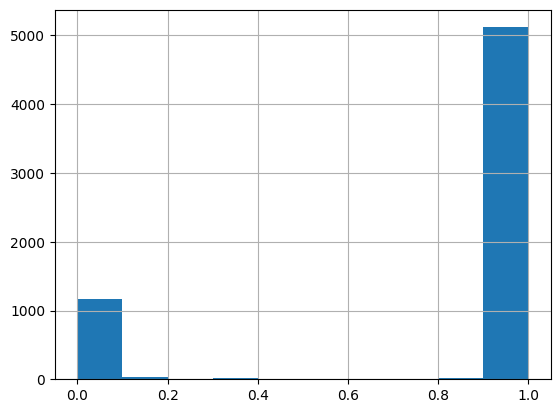

In [ ]:
pd.Series(y_prob).hist()

# Тест на новостях

In [ ]:
# original
paper = '''
Robert Fico and Aleksandar Vučić accept Vladimir Putin’s invitation to attend Victory Day celebrations
Despite warnings from European Union officials, Slovakia’s Moscow-friendly prime minister, Robert Fico, shook hands with Vladimir Putin at the Kremlin before becoming the only EU leader to attend Russia’s 9 May parade of military forces waging war on Ukraine.
The Serbian president, Aleksandar Vučić, whose country aspires to join the 27-nation union, also accepted the Russian president’s invitation to attend the annual Victory Day celebrations marking the defeat of Nazi Germany in the second world war.
The pair were the only European leaders to travel to Moscow after strong injunctions from EU officials not to do so. On Thursday, the bloc’s chief diplomat, Kaja Kallas, said: “All those who truly support peace cannot stand side-by-side with Putin. Those who truly support peace should be in Ukraine tomorrow, not Moscow.”
Kallas added this week that the Russian president was “waging a war right now, not a war from history. That remains on the conscience of those attending.”
Poland’s prime minister, Donald Tusk, who later on Friday was due to sign a cooperation and friendship treaty with France including joint security and defence commitments, sharply criticised both leaders, although he did so without naming them.
Tusk said: “For me it is unthinkable that one can be from this part of the world and, during Russia’s aggression against Ukraine, be in Red Square and celebrate Victory Day with those who are murdering children, civilians and attacking other countries.”
It is unclear what, if any, sanctions the EU could apply to either Bratislava or Belgrade. António Costa, the president of the European Council, is due to visit the Serbian capital on Monday. An EU official in Brussels suggested he would express criticism of the visits, saying: “We don’t engage only to pass easy and good messages.”
Kallas said last month that participation in the 9 May celebrations in Moscow would “not be taken lightly on the European side”. She called on representatives of EU member states and candidate countries to mark the day in Ukraine instead.
The EU foreign affairs chief was one of a 17-strong delegation of EU officials and foreign ministers, which also included the British foreign secretary, David Lammy, in Lviv on Friday to honour the victims of Russia’s war and back a special tribunal to investigate alleged Russian war crimes.
Fico, who last met Putin in December, said in April that “nobody will tell me where to go and where not to go”. He said he was going to “a commemorative event, that’s all”, to “pay homage to thousands of Red Army soldiers who died liberating Slovakia”.
The Slovakian prime minister, who has adopted Kremlin lines and sided with Hungary’s illiberal leader, Viktor Orbán, as a pro-Russian voice in the EU, also took part in bilateral meetings and attended a wreath-laying ceremony in Moscow.
'''.replace('\n', ' ')

inputs = tokenizer(paper, return_tensors='pt', truncation=True,
                    padding=True, max_length=512).to(device)
outputs = model_bert(**inputs)
cls_emb = outputs.last_hidden_state[:, 0, :].cpu().detach().numpy()

clf.predict_proba(cls_emb)[:, 1]

array([0.00556473])

In [ ]:
# original
paper = '''
Moscow stages largest Victory Day parade since start of Ukraine war with Putin using celebrations to justify invasion
Pjotr Sauer, and Shaun Walker in Kyiv

Russian troops fighting in Ukraine have marched with Chinese forces on Moscow’s Red Square to mark the 80th anniversary of Nazi Germany’s defeat in a Victory Day celebration marked by greater spectacle than in recent years.

After several scaled-back Victory Days – with reduced military displays and few foreign guests – Vladimir Putin on Friday addressed the largest parade since his 2022 full-scale invasion of Ukraine.

“The Soviet Union took upon itself the most ferocious, merciless blows of the enemy,” the Russian president said of the victory over Nazi Germany, before turning to his invasion of Ukraine. “Truth and justice are on our side. The entire country, society and people support the participants of the special military operation,” Putin said, using the Kremlin’s preferred term to describe the war.

While Putin was presiding over the parade, EU foreign ministers and Britain’s David Lammy travelled to Lviv in Ukraine where they announced the establishment of a tribunal for Russian war crimes. “Russia’s aggression cannot go unpunished and therefore establishing this tribunal is extremely important,” the EU’s top diplomat, Kaja Kallas, said during the visit.

Ukraine’s president, Volodymyr Zelenskyy, said he expected European leaders to visit Kyiv on Saturday, while European allies said at a meeting in Oslo that they supported an unconditional 30-day ceasefire in the war in Ukraine, something Moscow has been reluctant to agree to.

Moscow welcomed at least 27 foreign heads to the annual military parade, the highest number since 2015, including the leaders of Brazil, Slovakia and Serbia. The Kremlin presented the turnout as proof that it is not isolated, even four years into its war in Ukraine.

Other guests included leaders from fellow autocracies and pariah regimes, such as the military juntas from Myanmar and Burkina Faso.

Putin also thanked a visiting North Korean military delegation – a sign of deepening ties and new geopolitical realities after recent admissions from both sides that North Korean troops have been fighting alongside Russian forces in Ukraine.
'''.replace('\n', ' ')

inputs = tokenizer(paper, return_tensors='pt', truncation=True,
                    padding=True, max_length=512).to(device)
outputs = model_bert(**inputs)
cls_emb = outputs.last_hidden_state[:, 0, :].cpu().detach().numpy()

clf.predict_proba(cls_emb)[:, 1]

array([0.00909543])

In [ ]:
# generated
paper = '''
Slovakian and Serbian Leaders Defy EU Warnings to Attend Russian Military Parade

Bratislava/Belgrade, May 9, 2024 – In a move likely to strain relations with the European Union, Slovak Prime Minister Robert Fico and Serbian President Aleksandar Vučić attended Russia’s Victory Day military parade in Moscow, despite explicit disapproval from Brussels. The event, marking the Soviet Union’s victory over Nazi Germany in World War II, has become a symbol of Russian military might under President Vladimir Putin, who hosted the leaders amid ongoing tensions over the war in Ukraine.

Defiance Amid Diplomatic Tensions

The participation of Fico and Vučić signals a deliberate pivot toward Moscow, challenging the EU’s unified stance on isolating Russia. While most Western leaders boycotted the event, the Slovak and Serbian leaders’ presence underscores deepening divisions within Europe over relations with the Kremlin.

Fico, who has repeatedly criticized Western military aid to Ukraine, called the parade a "historic commemoration" and emphasized Slovakia’s "independent foreign policy."
Vučić, whose country remains an EU candidate but maintains close ties with Russia, praised "the sacrifices of the Soviet people" while avoiding direct mention of Ukraine.
EU Reaction: Frustration and Warnings

European officials expressed dismay, with one EU diplomat stating, "This is a provocation at a time when solidarity with Ukraine is crucial." While no immediate sanctions are expected, the move could complicate Slovakia’s and Serbia’s relations with Brussels, particularly as Serbia faces pressure to align with EU foreign policy.

Kremlin’s Symbolic Victory

Putin’s invitation to the leaders was seen as an attempt to showcase Russia’s enduring influence in Eastern Europe. State media highlighted their attendance as evidence that Western efforts to isolate Moscow have failed.

What’s Next?
Analysts suggest the EU may respond with stricter scrutiny of Serbia’s accession talks and Slovakia’s pro-Russian rhetoric. Meanwhile, the spectacle reinforces fears of a growing geopolitical rift in the Balkans and Central Europe.
'''.replace('\n', ' ')


inputs = tokenizer(paper, return_tensors='pt', truncation=True,
                    padding=True, max_length=512).to(device)
outputs = model_bert(**inputs)
cls_emb = outputs.last_hidden_state[:, 0, :].cpu().detach().numpy()


clf.predict_proba(cls_emb)[:, 1]

array([0.99999892])

In [ ]:
# generated
paper = '''
In a powerful display of military cooperation and diplomatic solidarity, Chinese troops marched alongside Russian forces through Moscow's Red Square on Thursday, marking the annual Victory Day parade. President Xi Jinping stood beside Russian President Vladimir Putin, underscoring the strengthening ties between the two nations amid heightened tensions with the West.

The parade commemorates the Soviet Union’s victory over Nazi Germany in World War II, and this year’s event carried added geopolitical symbolism. For the first time in several years, a significant Chinese military contingent participated in the procession, drawing global attention.

“Our cooperation knows no bounds,” President Xi stated in a brief address after the parade. “We honor the past, and together we are prepared for the future.”

The joint appearance follows a series of high-level meetings and military drills between the two countries, fueling speculation about a deepening strategic alliance. Western analysts view the gesture as a message to NATO and a reaffirmation of the Sino-Russian partnership.

Victory Day celebrations included not only the traditional military parade but also a moment of silence, wreath-laying ceremonies, and a flyover by the Russian Air Force. Crowds gathered in central Moscow, waving flags and cheering as the two leaders watched the event unfold from the grandstand.
'''.replace('\n', ' ')


inputs = tokenizer(paper, return_tensors='pt', truncation=True,
                    padding=True, max_length=512).to(device)
outputs = model_bert(**inputs)
cls_emb = outputs.last_hidden_state[:, 0, :].cpu().detach().numpy()


clf.predict_proba(cls_emb)[:, 1]

array([0.99999123])

# 4. PCA разложение

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score,calinski_harabasz_score
from sklearn.decomposition import PCA

In [ ]:
train_data_embed = pd.concat([train_data.reset_index(drop=True), pd.DataFrame(X_train)], axis=1)
test_data_embed = pd.concat([test_data.reset_index(drop=True), pd.DataFrame(X_test)], axis=1)

In [ ]:
# save_s3(pickle_data=train_data_embed, object_key='train_data_embed.pkl', client_s3=client_s3)
# save_s3(pickle_data=test_data_embed, object_key='test_data_embed.pkl', client_s3=client_s3)

# Скачаем датасет
train_data_embed = try_load(
    file_path=PATH+'data/',
    file_name='train_data_embed.pkl',
    client_s3=client_s3
    )

test_data_embed = try_load(
    file_path=PATH+'data/',
    file_name='test_data_embed.pkl',
    client_s3=client_s3
    )

Load pdf from s3: original news
Load pdf from s3: original news


In [ ]:
train_data_embed.iloc[:2, 6:]

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.223671,-0.061446,-0.158251,-0.442114,-0.109057,0.092521,0.337214,0.266578,-0.197714,0.147068,...,0.427914,0.010371,-0.139598,-0.180572,0.267232,0.388292,-0.299426,0.041205,0.429483,0.384048
1,-0.925184,-0.513057,-0.479291,-0.665422,-0.501323,0.282652,0.078905,-0.117293,0.550452,0.049249,...,0.724736,-0.084447,-0.090413,-0.228080,0.026700,-0.615514,-0.048534,-0.000165,0.205430,0.716191


**Davies-Bouldin Index** (+) измеряет среднее сходство между каждым кластером и его наиболее похожим кластером, нормированное средним сходством между каждым кластером и его наименее похожим кластером. Более низкие значения этого индекса говорят о лучшей разделимости кластеров.  1

**Silhouette Score** (-) показывает, насколько хорошо определены кластеры, путём вычисления среднего расстояния между точками данных внутри кластера и среднего расстояния между точками данных в ближайшем кластере. Значения Silhouette Score находятся в диапазоне от -1 до 1, более высокие значения указывают на лучше определённые кластеры.  1

**Calinski-Harabasz Index** (-) измеряет отношение дисперсии между кластерами к дисперсии внутри кластеров. Более высокие значения этого индекса указывают на более чётко определённые кластеры.

**Explained Variance** (-) — это показатель того, насколько модель способна объяснить вариацию в данных. Чем выше значение Explained Variance, тем лучше модель может это делать.

In [ ]:
guardtian_llm_papers = {
    'guardian_rw_dsv3_1' : 'Guardian, переписанные DeepSeek-v3',
    'guardian_rw_dsv3_2' : 'Guardian, переписанные DeepSeek-v3, SRv1',
    'guardian_rw_dsv3_3' : 'Guardian, переписанные DeepSeek-v3, SRv2',
    'guardian_rw_dsv3_4' : 'Guardian, переписанные DeepSeek-v3, SRv3',
    'guardian_rw_dsv3_5' : 'Guardian, переписанные DeepSeek-v3, SRv4',
    'guardian_rw_dsv3_6' : 'Guardian, переписанные DeepSeek-v3, SRv5',
    'guardian_rw_phi_35' : 'Guardian, переписанные PHI-3.5',
    'guardian_rw_gemeni_1' : 'Guardian, переписанные Gemeni',
    'guardian_rw_gemeni_2' : 'Guardian, переписанные Gemeni, SRv1'
    }

pca_metrics = pd.DataFrame()

for llm_paper_name in guardtian_llm_papers.keys():

  # Данные: эмбеддинги и метки
  X = train_data_embed[
      (train_data_embed['describ'].isin(['guardian_orig', llm_paper_name])) &
      (train_data_embed['augment_data']==0) &
      (train_data_embed['cut_news']==0)
      ].iloc[:, 6:].values

  y = train_data_embed[
      (train_data_embed['describ'].isin(['guardian_orig', llm_paper_name])) &
      (train_data_embed['augment_data']==0) &
      (train_data_embed['cut_news']==0)
      ].iloc[:, 3].values

  # PCA до 2 компонент
  pca = PCA(n_components=2)
  X_pca = pca.fit_transform(X)

  # 2. Вычисление метрик
  silhouette = silhouette_score(X_pca, y)
  db_score = davies_bouldin_score(X_pca, y)
  ch_score = calinski_harabasz_score(X_pca, y)
  explained_var = pca.explained_variance_ratio_.sum()

  print(f'{guardtian_llm_papers[llm_paper_name]}, Silhouette score: {silhouette:.4f}, Davies Bouldin score: {db_score:.4f}, Calinski Harabasz score: {ch_score:.1f}, Explained variance ratio: {explained_var:.4f}')

Guardian, переписанные DeepSeek-v3, Silhouette score: 0.1883, Davies Bouldin score: 1.6164, Calinski Harabasz score: 506.2, Explained variance ratio: 0.2313
Guardian, переписанные DeepSeek-v3, SRv1, Silhouette score: 0.1987, Davies Bouldin score: 1.7135, Calinski Harabasz score: 430.6, Explained variance ratio: 0.2289
Guardian, переписанные DeepSeek-v3, SRv2, Silhouette score: 0.3086, Davies Bouldin score: 1.2893, Calinski Harabasz score: 795.3, Explained variance ratio: 0.2829
Guardian, переписанные DeepSeek-v3, SRv3, Silhouette score: 0.2863, Davies Bouldin score: 1.3785, Calinski Harabasz score: 668.9, Explained variance ratio: 0.2446
Guardian, переписанные DeepSeek-v3, SRv4, Silhouette score: 0.3543, Davies Bouldin score: 0.9300, Calinski Harabasz score: 1368.6, Explained variance ratio: 0.2909
Guardian, переписанные DeepSeek-v3, SRv5, Silhouette score: 0.3785, Davies Bouldin score: 0.9614, Calinski Harabasz score: 1327.7, Explained variance ratio: 0.2603
Guardian, переписанные PHI

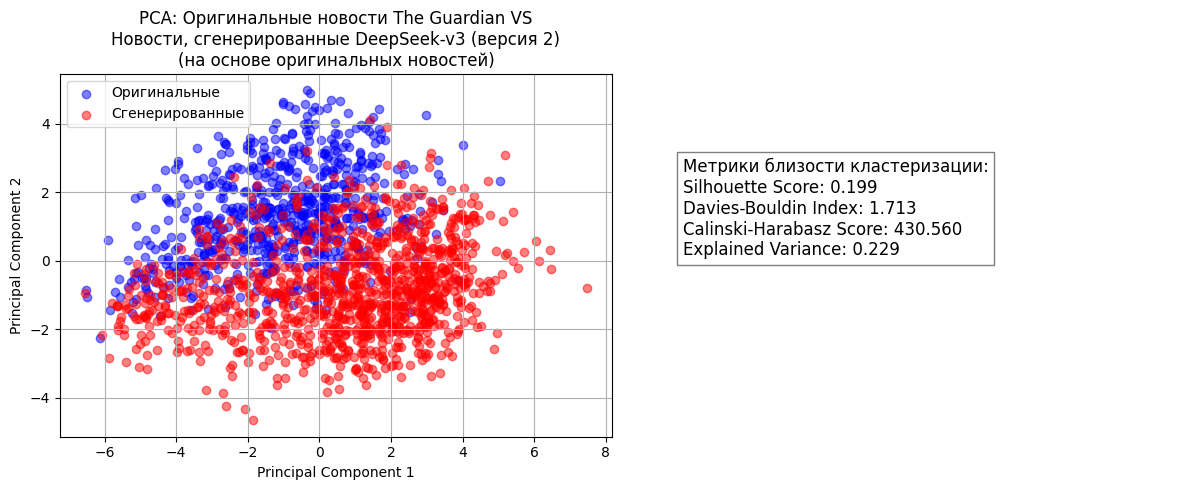

In [ ]:
# Данные: эмбеддинги и метки
X = train_data_embed[
    (train_data_embed['describ'].isin(['guardian_orig', 'guardian_rw_dsv3_2'])) &
    (train_data_embed['augment_data']==0) &
    (train_data_embed['cut_news']==0)
    ].iloc[:, 6:].values

y = train_data_embed[
    (train_data_embed['describ'].isin(['guardian_orig', 'guardian_rw_dsv3_2'])) &
    (train_data_embed['augment_data']==0) &
    (train_data_embed['cut_news']==0)
    ].iloc[:, 3].values

# PCA до 2 компонент
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 1. Визуализация
plt.figure(figsize=(12, 5))

# График PCA
plt.subplot(1, 2, 1)
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], color='blue', label='Оригинальные', alpha=0.5)
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], color='red', label='Сгенерированные', alpha=0.5)
plt.legend()
plt.title('PCA: Оригинальные новости The Guardian VS\nНовости, сгенерированные DeepSeek-v3 (версия 2)\n(на основе оригинальных новостей)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# 2. Вычисление метрик
silhouette = silhouette_score(X_pca, y)
db_score = davies_bouldin_score(X_pca, y)
ch_score = calinski_harabasz_score(X_pca, y)
explained_var = pca.explained_variance_ratio_.sum()

# Вывод метрик
metrics_text = (
    f"Метрики близости кластеризации:\n"
    f"Silhouette Score: {silhouette:.3f}\n"
    f"Davies-Bouldin Index: {db_score:.3f}\n"
    f"Calinski-Harabasz Score: {ch_score:.3f}\n"
    f"Explained Variance: {explained_var:.3f}"
)

plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, metrics_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.axis('off')

plt.tight_layout()
plt.show()

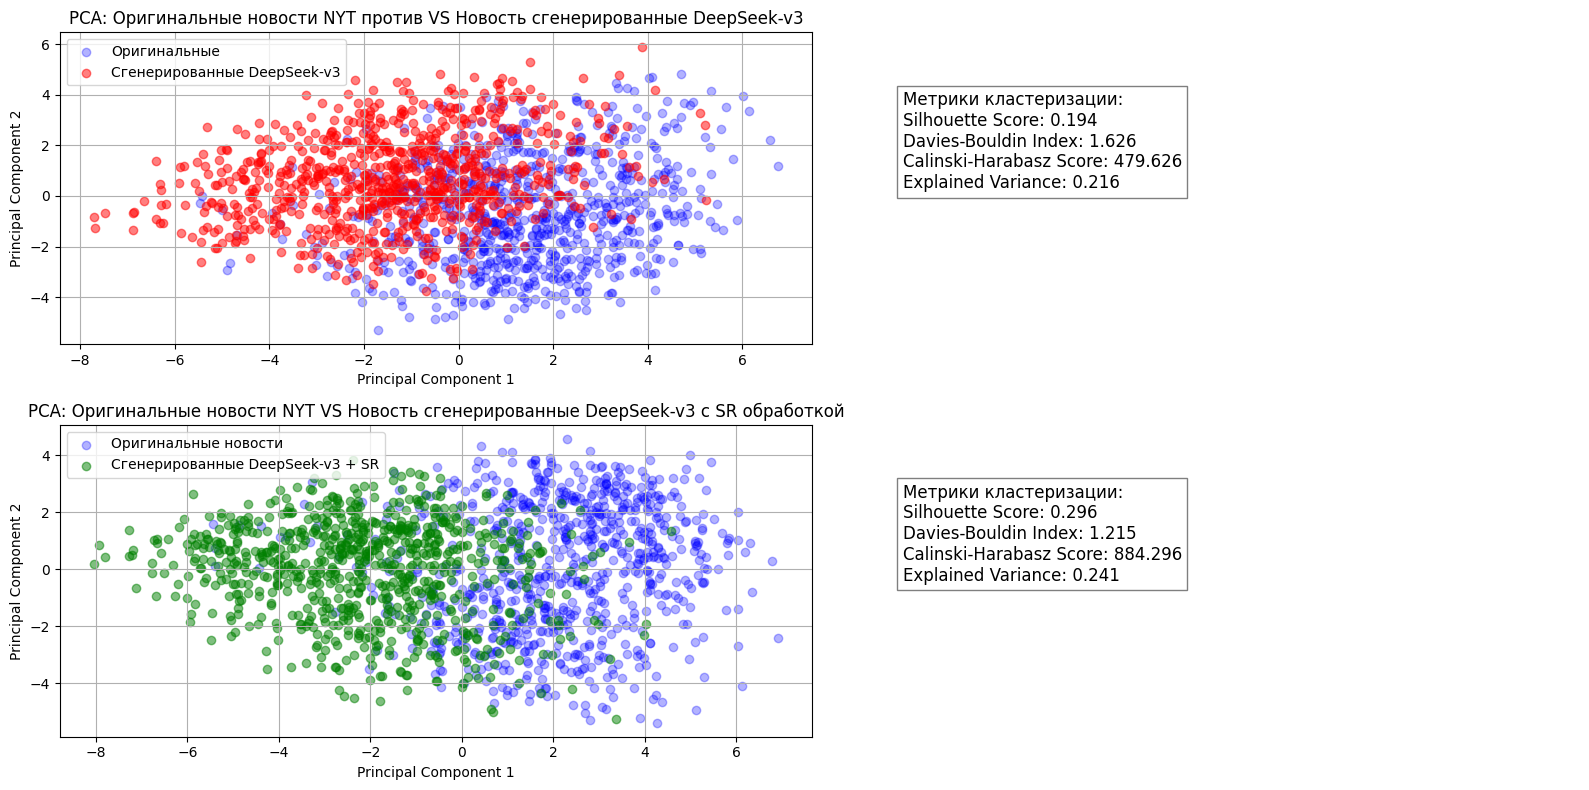

In [ ]:
# Создаем фигуру с 2 рядами и 4 колонками (2 графика + 2 метрики для каждого случая)
plt.figure(figsize=(16, 8))

# Первый случай: nyt_rw_dsv3_1
X1 = train_data_embed[
    (train_data_embed['describ'].isin(['nyt_orig', 'nyt_rw_dsv3_1'])) &
    (train_data_embed['augment_data']==0) &
    (train_data_embed['cut_news']==0)
    ].iloc[:, 6:].values

y1 = train_data_embed[
    (train_data_embed['describ'].isin(['nyt_orig', 'nyt_rw_dsv3_1'])) &
    (train_data_embed['augment_data']==0) &
    (train_data_embed['cut_news']==0)
    ].iloc[:, 3].values

# PCA для первого случая
pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X1)

# График PCA для первого случая
plt.subplot(2, 2, 1)
plt.scatter(X_pca1[y1==1, 0], X_pca1[y1==1, 1], color='blue', label='Оригинальные', alpha=0.3)
plt.scatter(X_pca1[y1==0, 0], X_pca1[y1==0, 1], color='red', label='Сгенерированные DeepSeek-v3', alpha=0.5)
plt.legend()
plt.title('PCA: Оригинальные новости NYT VS Новость сгенерированные DeepSeek-v3')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Метрики для первого случая
silhouette1 = silhouette_score(X_pca1, y1)
db_score1 = davies_bouldin_score(X_pca1, y1)
ch_score1 = calinski_harabasz_score(X_pca1, y1)
explained_var1 = pca1.explained_variance_ratio_.sum()

metrics_text1 = (
    f"Метрики кластеризации:\n"
    f"Silhouette Score: {silhouette1:.3f}\n"
    f"Davies-Bouldin Index: {db_score1:.3f}\n"
    f"Calinski-Harabasz Score: {ch_score1:.3f}\n"
    f"Explained Variance: {explained_var1:.3f}"
)

plt.subplot(2, 2, 2)
plt.text(0.1, 0.5, metrics_text1, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.axis('off')
# plt.title('Cluster Quality Metrics (dsv3_1)')

# Второй случай: guardian_rw_dsv3_2
X2 = train_data_embed[
    (train_data_embed['describ'].isin(['nyt_orig', 'nyt_rw_dsv3_3'])) &
    (train_data_embed['augment_data']==0) &
    (train_data_embed['cut_news']==0)
    ].iloc[:, 6:].values

y2 = train_data_embed[
    (train_data_embed['describ'].isin(['nyt_orig', 'nyt_rw_dsv3_3'])) &
    (train_data_embed['augment_data']==0) &
    (train_data_embed['cut_news']==0)
    ].iloc[:, 3].values

# PCA для второго случая
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X2)

# График PCA для второго случая
plt.subplot(2, 2, 3)
plt.scatter(X_pca2[y2==1, 0], X_pca2[y2==1, 1], color='blue', label='Оригинальные новости', alpha=0.3)
plt.scatter(X_pca2[y2==0, 0], X_pca2[y2==0, 1], color='green', label='Сгенерированные DeepSeek-v3 + SR', alpha=0.5)
plt.legend()
plt.title('PCA: Оригинальные новости NYT VS Новость сгенерированные DeepSeek-v3 с SR обработкой')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Метрики для второго случая
silhouette2 = silhouette_score(X_pca2, y2)
db_score2 = davies_bouldin_score(X_pca2, y2)
ch_score2 = calinski_harabasz_score(X_pca2, y2)
explained_var2 = pca2.explained_variance_ratio_.sum()

metrics_text2 = (
    f"Метрики кластеризации:\n"
    f"Silhouette Score: {silhouette2:.3f}\n"
    f"Davies-Bouldin Index: {db_score2:.3f}\n"
    f"Calinski-Harabasz Score: {ch_score2:.3f}\n"
    f"Explained Variance: {explained_var2:.3f}"
)

plt.subplot(2, 2, 4)
plt.text(0.1, 0.5, metrics_text2, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.axis('off')
# plt.title('Cluster Quality Metrics (dsv3_2)')

plt.tight_layout()
plt.show()

In [ ]:
nyt_llm_papers = {
    'nyt_rw_dsv3_1' : 'New York Times, переписанные DeepSeek-v3, SRv1',
    'nyt_rw_dsv3_2' : 'New York Times, переписанные DeepSeek-v3, SRv2',
    'nyt_rw_dsv3_3' : 'New York Times, переписанные DeepSeek-v3, SRv3',
    'nyt_rw_dsv3_4' : 'New York Times, переписанные DeepSeek-v3, SRv4',
    }

for llm_paper_name in nyt_llm_papers.keys():

  # Данные: эмбеддинги и метки
  X = train_data_embed[
      (train_data_embed['describ'].isin(['nyt_orig', llm_paper_name])) &
      (train_data_embed['augment_data']==0) &
      (train_data_embed['cut_news']==0)
      ].iloc[:, 6:].values

  y = train_data_embed[
      (train_data_embed['describ'].isin(['nyt_orig', llm_paper_name])) &
      (train_data_embed['augment_data']==0) &
      (train_data_embed['cut_news']==0)
      ].iloc[:, 3].values

  # PCA до 2 компонент
  pca = PCA(n_components=2)
  X_pca = pca.fit_transform(X)

  # 2. Вычисление метрик
  silhouette = silhouette_score(X_pca, y)
  db_score = davies_bouldin_score(X_pca, y)
  ch_score = calinski_harabasz_score(X_pca, y)
  explained_var = pca.explained_variance_ratio_.sum()

  print(f'{nyt_llm_papers[llm_paper_name]}, Silhouette score: {silhouette:.4f}, Davies Bouldin score: {db_score:.4f}, Calinski Harabasz score: {ch_score:.1f}, Explained variance ratio: {explained_var:.4f}')

New York Times, переписанные DeepSeek-v3, SRv1, Silhouette score: 0.1940, Davies Bouldin score: 1.6265, Calinski Harabasz score: 479.6, Explained variance ratio: 0.2156
New York Times, переписанные DeepSeek-v3, SRv2, Silhouette score: 0.2865, Davies Bouldin score: 1.2844, Calinski Harabasz score: 740.3, Explained variance ratio: 0.2191
New York Times, переписанные DeepSeek-v3, SRv3, Silhouette score: 0.2959, Davies Bouldin score: 1.2146, Calinski Harabasz score: 884.3, Explained variance ratio: 0.2414
New York Times, переписанные DeepSeek-v3, SRv4, Silhouette score: 0.3010, Davies Bouldin score: 1.2763, Calinski Harabasz score: 757.9, Explained variance ratio: 0.2245


In [ ]:
ds_llm_papers = {
    'dsv3_news_1' : 'New York Times, Написанные DeepSeek-v3',
    'dsv3_news_2' : 'New York Times, Написанные DeepSeek-v3, SRv1',
    }

for llm_paper_name in ds_llm_papers.keys():

  # Данные: эмбеддинги и метки
  X = train_data_embed[
      (train_data_embed['describ'].isin(['nyt_orig', llm_paper_name])) &
      (train_data_embed['augment_data']==0) &
      (train_data_embed['cut_news']==0)
      ].iloc[:, 6:].values

  y = train_data_embed[
      (train_data_embed['describ'].isin(['nyt_orig', llm_paper_name])) &
      (train_data_embed['augment_data']==0) &
      (train_data_embed['cut_news']==0)
      ].iloc[:, 3].values

  # PCA до 2 компонент
  pca = PCA(n_components=2)
  X_pca = pca.fit_transform(X)

  # 2. Вычисление метрик
  silhouette = silhouette_score(X_pca, y)
  db_score = davies_bouldin_score(X_pca, y)
  ch_score = calinski_harabasz_score(X_pca, y)
  explained_var = pca.explained_variance_ratio_.sum()

  print(f'{ds_llm_papers[llm_paper_name]}, Silhouette score: {silhouette:.4f}, Davies Bouldin score: {db_score:.4f}, Calinski Harabasz score: {ch_score:.1f}, Explained variance ratio: {explained_var:.4f}')

New York Times, Написанные DeepSeek-v3, Silhouette score: 0.5047, Davies Bouldin score: 0.7418, Calinski Harabasz score: 1461.3, Explained variance ratio: 0.2764
New York Times, Написанные DeepSeek-v3, SRv1, Silhouette score: 0.4735, Davies Bouldin score: 0.8028, Calinski Harabasz score: 1236.6, Explained variance ratio: 0.2649


In [ ]:
ds_llm_papers = {
    'dsv3_news_1' : 'Guardian, Написанные DeepSeek-v3',
    'dsv3_news_2' : 'Guardian, Написанные DeepSeek-v3, SRv1',
    }

for llm_paper_name in ds_llm_papers.keys():

  # Данные: эмбеддинги и метки
  X = train_data_embed[
      (train_data_embed['describ'].isin(['guardian_orig', llm_paper_name])) &
      (train_data_embed['augment_data']==0) &
      (train_data_embed['cut_news']==0)
      ].iloc[:, 6:].values

  y = train_data_embed[
      (train_data_embed['describ'].isin(['guardian_orig', llm_paper_name])) &
      (train_data_embed['augment_data']==0) &
      (train_data_embed['cut_news']==0)
      ].iloc[:, 3].values

  # PCA до 2 компонент
  pca = PCA(n_components=2)
  X_pca = pca.fit_transform(X)

  # 2. Вычисление метрик
  silhouette = silhouette_score(X_pca, y)
  db_score = davies_bouldin_score(X_pca, y)
  ch_score = calinski_harabasz_score(X_pca, y)
  explained_var = pca.explained_variance_ratio_.sum()

  print(f'{ds_llm_papers[llm_paper_name]}, Silhouette score: {silhouette:.4f}, Davies Bouldin score: {db_score:.4f}, Calinski Harabasz score: {ch_score:.1f}, Explained variance ratio: {explained_var:.4f}')

Guardian, Написанные DeepSeek-v3, Silhouette score: 0.5507, Davies Bouldin score: 0.6540, Calinski Harabasz score: 1959.1, Explained variance ratio: 0.3140
Guardian, Написанные DeepSeek-v3, SRv1, Silhouette score: 0.5395, Davies Bouldin score: 0.6680, Calinski Harabasz score: 1829.0, Explained variance ratio: 0.3115
